<img src=https://www.udc.es/export/sites/udc/silazarillo/_galeria_imgs/03_Simbolo_logo_cor.png_2063069294.png width="300" align="left">
<br />

# Modelos Avanzados de Aprendizaje automático II
#### <font color=green>*Grado en Inteligencia Artificial*</font>

# Tema 1: Agrupamiento (clustering)

#### Ejercicio sobre el uso de algoritmos de agrupamiento ($k$-medias y DBSCAN) sobre los siguientes conjuntos de datos:
#### 1. Conjunto de datos artificial de 2 dimensiones con 3 grupos (clústeres).
#### 2. Conjunto de datos artificial de 32 dimensiones con 16 grupos (clústeres).

#### Se cargan las librerías necesarias:

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mode
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, ConfusionMatrixDisplay
from sklearn.metrics.cluster import v_measure_score, rand_score
from sklearn.datasets import make_blobs
import seaborn as sns

### Caso 1: Conjunto de datos artificial de 2 dimensiones con 3 grupos (clústeres).

#### Se generan 200 datos artificiales en 2 dimensiones empleando la función [make_blobs](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html) de la librería scikit-learn. Para ello se generarán datos con distribuciones Gaussians isotrópicas con 3 centros diferentes y desviación típica de 0.5:

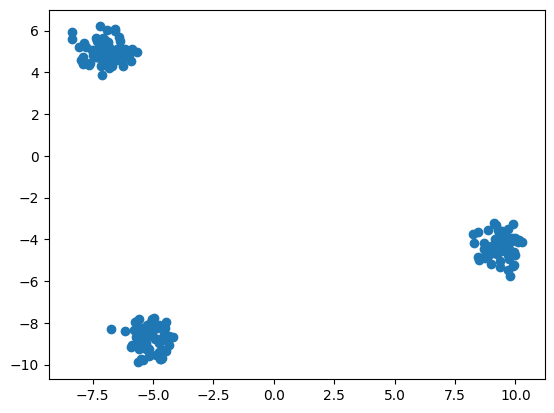

In [46]:
blobs = make_blobs(200, 2, centers=3, cluster_std=0.5, return_centers=True)
plt.scatter(blobs[0][:, 0], blobs[0][:, 1])
plt.show()

#### Se realiza el agrupamiento (clustering) mediante el uso del método [$k$-medias](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html), con inicialización aleatoria de centroides. Para determinar el mejor valor de $k$ se probará con valores entre 1 y 15 y se guardará en una lista la medida de inercia de cada uno de los modelos:

In [ ]:
inertias = []
K = np.arange(1, 16)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=5, init="random", n_init="auto").fit(blobs[0])
    inertias.append(kmeans.inertia_)


#### Se muestra gráficamente el valor de la inercia con los valores de $k$ entre 1 y 15 para poder determinar el mejor valor de $k$:

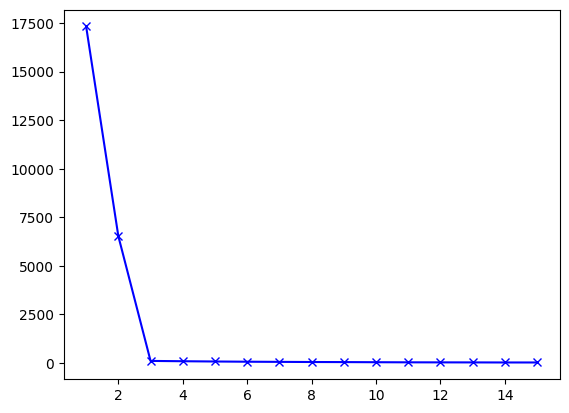

In [63]:
plt.plot(K, inertias, color="blue", marker="x")
plt.show()

#### Se muestra gráficamente el resultado del agrupamiento para el mejor valor de $k$ observando la gráfica anterior. Para ello, se realizará de nuevo el entrenamiento del modelo para ese valor concreto de $k$. En la gráfica se mostrará también el centroide de cada grupo mediante el uso de punto en color rojo. Para crear la gráfica se recomienda el uso del método [scatter](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) y el método [legend_elements](https://matplotlib.org/stable/api/collections_api.html#matplotlib.collections.PathCollection.legend_elements) para definir los elementos de la leyenda:

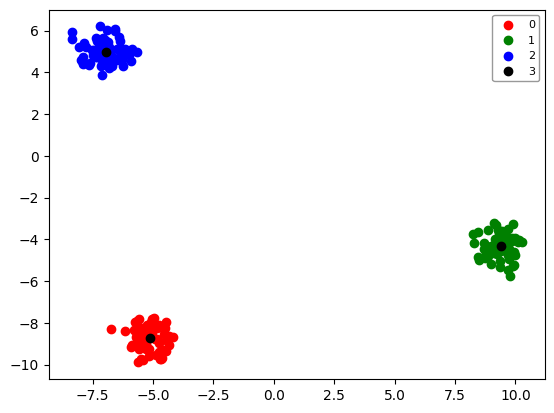

In [67]:
def draw(pts, labels):
    ulab = np.unique(labels)
    colors = dict(zip(ulab, ["red", "green", "blue", "black"]))
    fig = plt.figure()
    if np.shape(pts)[1] == 3:
        ax = fig.add_subplot(projection="3d")
        for key in colors:
            mask = [i == key for i in labels]
            ax.scatter(pts[:, 0][mask], pts[:, 1][mask], pts[:, 2][mask], c=colors[key], label = key)
    else:
        ax = fig.add_subplot()
        for key in colors:
            mask = [i == key for i in labels]
            ax.scatter(pts[:, 0][mask], pts[:, 1][mask], c=colors[key], label = key,)
    plt.legend(fontsize=8, frameon=True, framealpha=0.8, edgecolor='gray')
    plt.show()
kmeans = KMeans(n_clusters=3, random_state=5, init="random", n_init="auto").fit(blobs[0])
draw(np.concatenate([blobs[0], blobs[2]]), np.concatenate([kmeans.labels_, [3 for i in range(3)]]))

#### Cálculo del coeficiente de silueta ([Silhouette Coefficient](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html)). Para determinar el mejor valor de $k$ se probará con valores entre 2 y 15 y se guardará en una lista el valor de coeficiente para cada uno de los modelos:

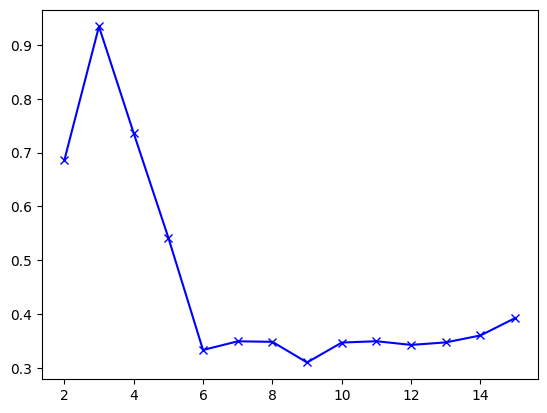

In [ ]:
sil = []
K = np.arange(2, 16)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=5, init="random", n_init="auto").fit(blobs[0])
    sil.append(silhouette_score(blobs[0], kmeans.labels_))
plt.plot(K, sil, color="blue", marker="x")
plt.show()


#### Cálculo de la medida V ([V measure](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.v_measure_score.html)). Para determinar el mejor valor de $k$ se probará con valores entre 2 y 15 y se guardará en una lista el valor de la medida para cada uno de los modelos:

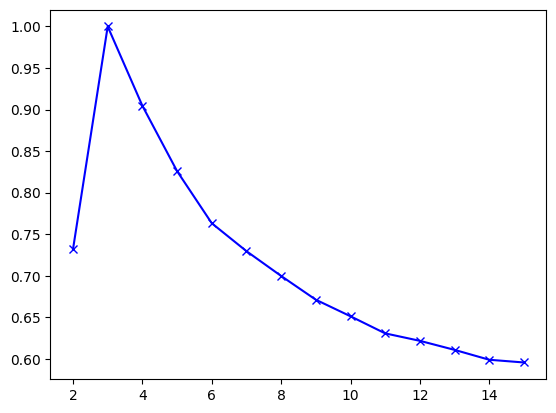

In [71]:
v = []
K = np.arange(2, 16)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=5, init="random", n_init="auto").fit(blobs[0])
    v.append(v_measure_score(blobs[1], kmeans.labels_))
plt.plot(K, v, color="blue", marker="x")
plt.show()

#### Cálculo de las medidas índice Rand ([Rand index](https://scikit-learn.org/stable/modules/clustering.html#rand-index)) e índice Rand ajustado. De nuevo se probarán valores de $k$ entre 2 y 15 y se guardará en una lista el valor de la medida para cada uno de los modelos. 

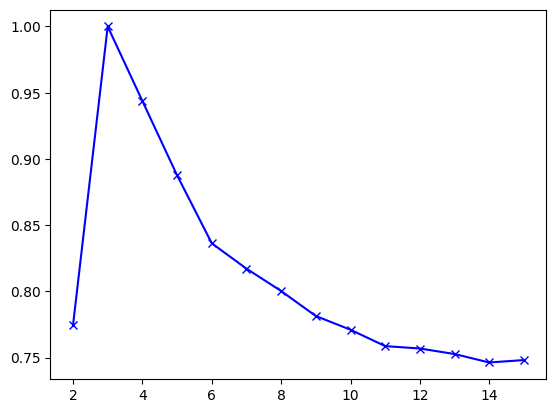

In [72]:
rnd = []
K = np.arange(2, 16)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=5, init="random", n_init="auto").fit(blobs[0])
    rnd.append(rand_score(blobs[1], kmeans.labels_))
plt.plot(K, rnd, color="blue", marker="x")
plt.show()

### Repetir todo el proceso para una inicialización de centroides con $k-means++$

In [ ]:
# 




## DBSCAN

#### Se realiza el agrupamiento (clustering) mediante el uso del método [DBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html). Para determinar el mejor valor de $epsilon$ se calculará la $k$-distancia de cada punto, siendo $k$ = minPts, y se mostrarán gráficamente las $k$-distancias ordenadas de menor a mayor. Para poder determinar la $k$-distancia se recomienda el uso de la función [NearestNeighbors](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html) y para ordenarlas la función [sort](https://numpy.org/doc/stable/reference/generated/numpy.sort.html):

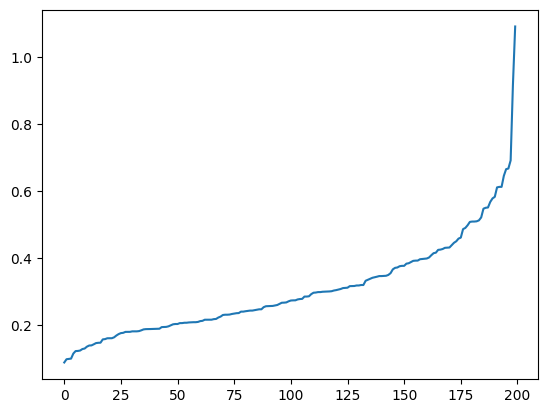

In [114]:
srted = np.sort(NearestNeighbors(n_neighbors=5).fit(blobs[0]).kneighbors(blobs[0])[0], axis=0)
plt.plot(srted[:, -1])
plt.show()

#### Se muestra gráficamente el resultado de agrupamiento con DBSCAN para el mejor valor estimado de minPts y $epsilon$. Se indicará también el número de grupos (clústeres) creados y el número de datos clasificados como ruido:

Grupos detectados: 3
Datos clasificados como ruido: 3


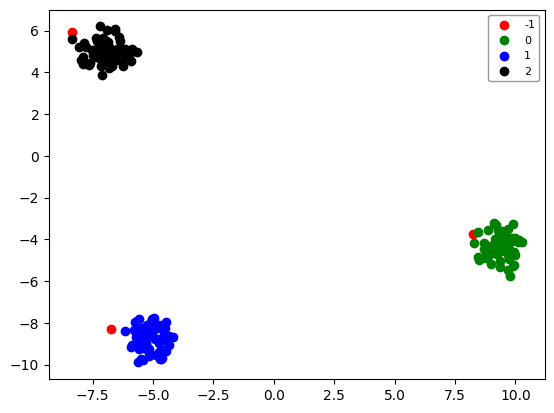

In [120]:
dbscan = DBSCAN(0.55, min_samples=5).fit(blobs[0])
print("Grupos detectados:", len(np.unique(dbscan.labels_)) - 1)
print("Datos clasificados como ruido:", np.count_nonzero(dbscan.labels_ == -1))
draw(blobs[0], dbscan.labels_)

#### Se realiza el agrupamiento (clustering) con el método jerárquico mediante el uso de la función [linkage](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html). Para ello, es necesario calcular previamente la matriz de distancias de los datos usando, por ejemplo, la función [pdist](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.pdist.html):

#### Se muestra el dendrograma asociado al método jerárquico con la función [dendrogram](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.dendrogram.html):

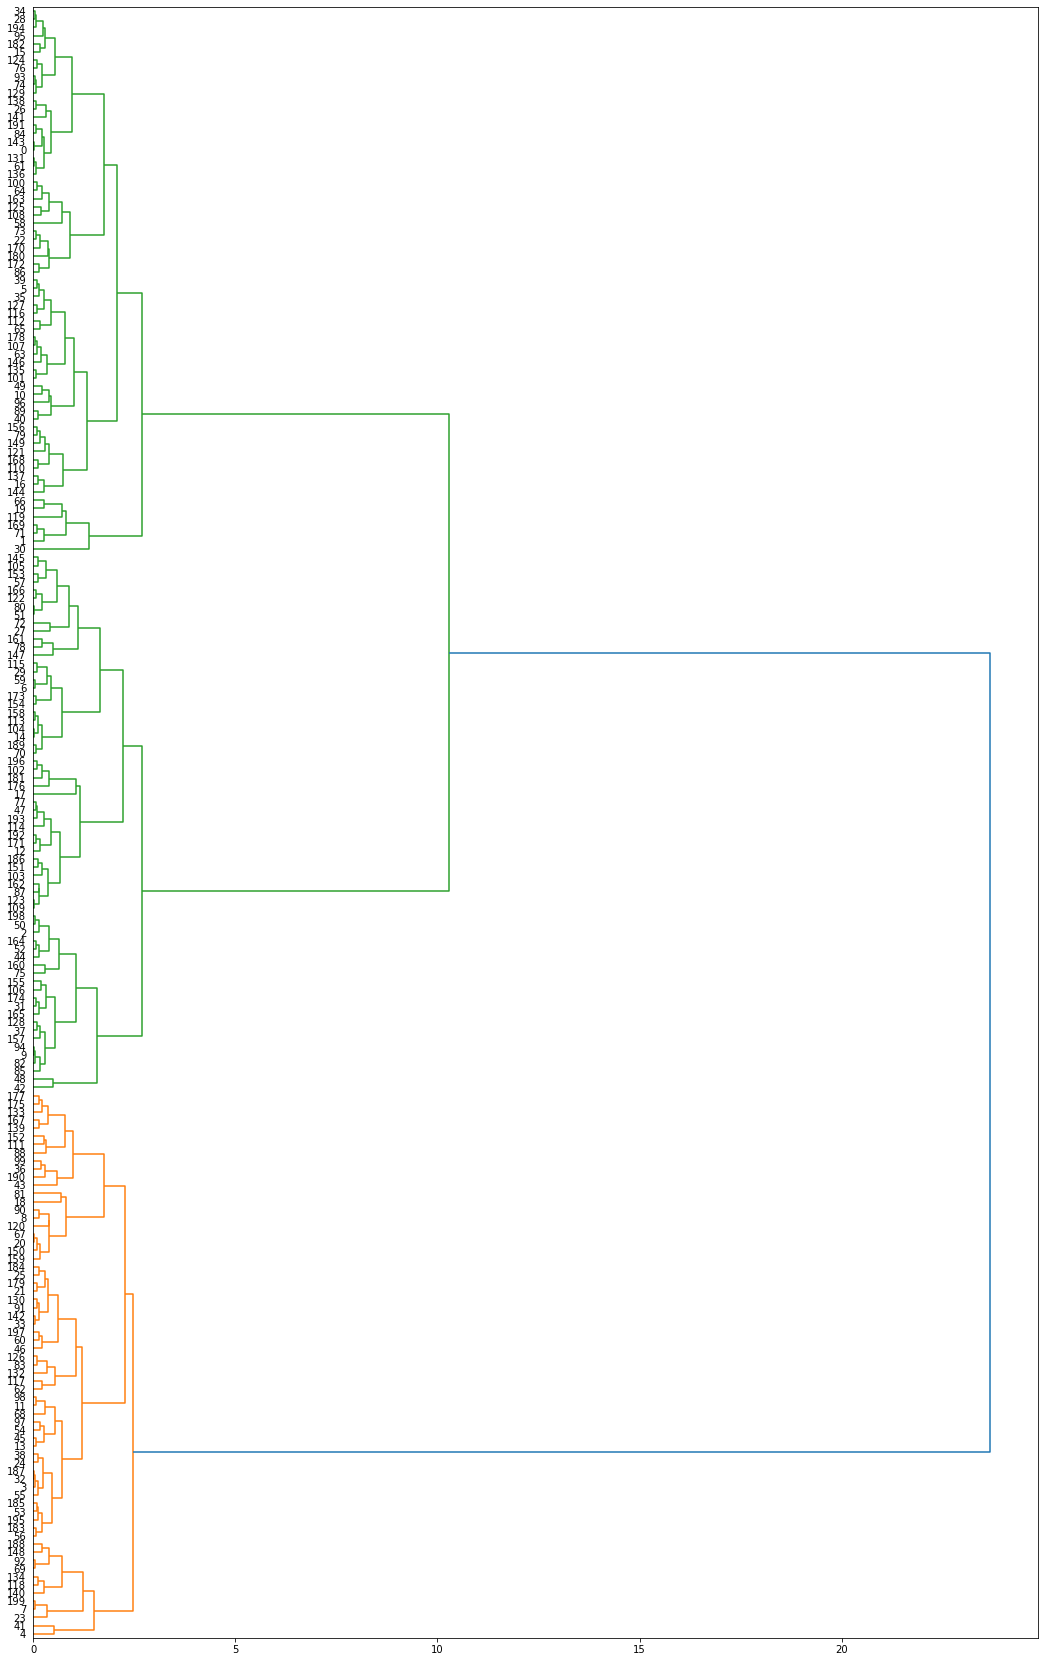

#### Se muestra el resultado del agrupamiento jerárquico con la función [fcluster](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.fcluster.html). Emplear para ello el argumento criterion='maxclust' para seleccionar el número de grupos:

Número de grupos:  3


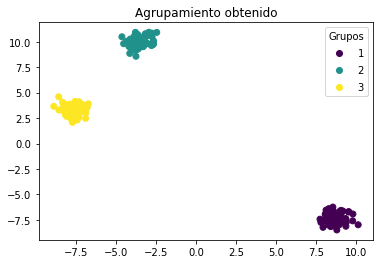

## Caso 2: Conjunto de datos artificial de 32 dimensiones con 16 grupos (clústeres).

#### Se carga de fichero (dim032.txt) con el conjunto de datos procedente de la página web [Clustering basic benchmark](http://cs.joensuu.fi/sipu/datasets/). Se recomienda el uso de la función [loadtxt](https://numpy.org/doc/stable/reference/generated/numpy.loadtxt.html) para la lectura de los datos:

Datos:  1024
Variables:  32


#### Se realiza el agrupamiento (clustering) mediante el uso del método [$k$-medias](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html). Para determinar el mejor valor de $k$ se probará con valores entre 2 y 30 y se guardarán en listas la medida de inercia y el valor del coeficiente de silueta ([Silhouette Coefficient](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html)) de cada uno de los modelos:

#### Se muestra en una misma gráfica el valor de la inercia y del coeficiente de silueta, con los valores de $k$ entre 2 y 30, para poder determinar el mejor valor de $k$:

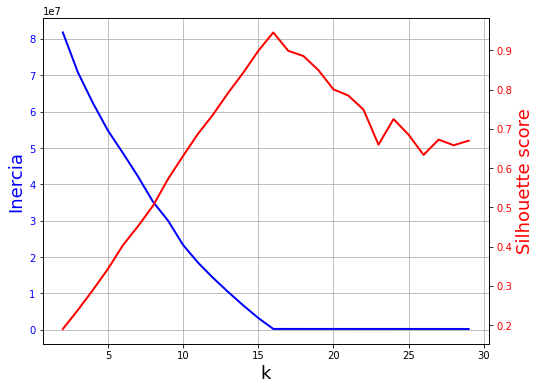

#### Se realiza el agrupamiento (clustering) mediante el uso del método [DBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html). Para determinar el mejor valor de $epsilon$ se calculará la $k$-distancia de cada punto, siendo $k$ = minPts, y se mostrarán gráficamente las $k$-distancias ordenadas de menor a mayor. Para poder determinar la $k$-distancia se recomienda el uso de la función [NearestNeighbors](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html) y para ordenarlas la función [sort](https://numpy.org/doc/stable/reference/generated/numpy.sort.html):

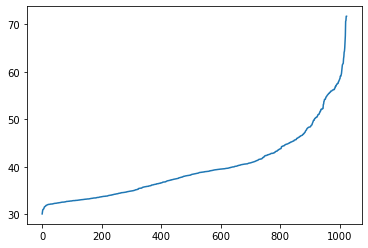

#### Se entrena el modelo con DBSCAN para el mejor valor estimado de minPts y $epsilon$. Se muestran el número de grupos (clústeres) creados y el número de datos clasificados como ruido:

Grupos detectados:  16
Datos clasificados como ruido:  0


#### En este caso no podemos visualizar los resultados directamente ya que el espacio de los datos tiene 32 dimensiones. Por ello, transformaremos los datos empleando el método [t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html), que hemos estudiado en el tema de reducción de la dimensión, y seleccionaremos solo los 2 primeros componentes del espacio transformado. Con esos 2 componentes, mostremos gráficamente el agrupamiento realizado por el DBSCAN:

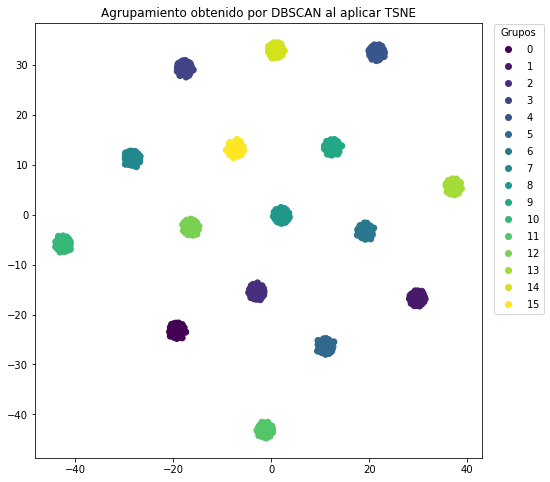